- 각 변수는 어떤 값을 갖는가?
- 각 품종의 데이터 수는 동일한가?
- 꽃잎과 꽃받침의 크기는 어떻게 분포하는가?
- 이상치로 보이는 관측값은 존재하는가?
- 꽃잎 길이와 너비는 서로 어떠한 관계를 갖는가?
- 품종에 따라 측정값의 분포가 다른가?
- 여러 수치형 변수 중 어떤 변수들이 강한 관계를 갖는가?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [2]:
sns.set_theme(
    context='notebook',
    style='whitegrid',
)

In [6]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()

In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df = df.rename(
    columns={
        'sepal length (cm)': 'sepal_length',
        'sepal width (cm)': 'sepal_width',
        'petal length (cm)': 'petal_length',
        'petal width (cm)': 'petal_width',
    }
)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [16]:
target_map = dict(enumerate(iris.target_names))

df['species'] = df['target'].map(target_map)
df = df.drop(columns='target')

In [17]:
df.shape

(150, 5)

In [18]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [19]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [20]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [22]:
numeric_columns = df.select_dtypes(include='number').columns.to_list()

print(type(numeric_columns))
print(numeric_columns)

<class 'list'>
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [23]:
categorical_columns = df.select_dtypes(exclude='number').columns.to_list()

print(type(categorical_columns))
print(categorical_columns)

<class 'list'>
['species']


In [24]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [25]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [27]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 꽃잎 길이는 어떤 분포를 갖고 있는가?
- 사용할 변수: petal_length

## 품종마다 꽃잎 길이가 다른가?
- 사용할 변수: species, petal_length

## 꽃잎 길이와 꽃잎 너비사이에 관계가 있는가?
- 사용할 변수: petal_length, petal_width

## 꽃잎 길이와 너비의 관계가 품종에 따라 다르게 나타나는가?
- 사용할 변수: petal_length, petal_width, species

## 네가지 수치형 변수 전체에서는 어떤 관계가 나타나는가?
- 사용할 변수: 모든 수치형 변수

## 단변량 변수

수치형 변수
- 중심의 위치
- 전체 범위
- 분포의 모양
- 값이 집중된 영역
- 극단적으로 떨어진 관측값


In [28]:
df['petal_length'].describe().round(2)

count    150.00
mean       3.76
std        1.77
min        1.00
25%        1.60
50%        4.35
75%        5.10
max        6.90
Name: petal_length, dtype: float64

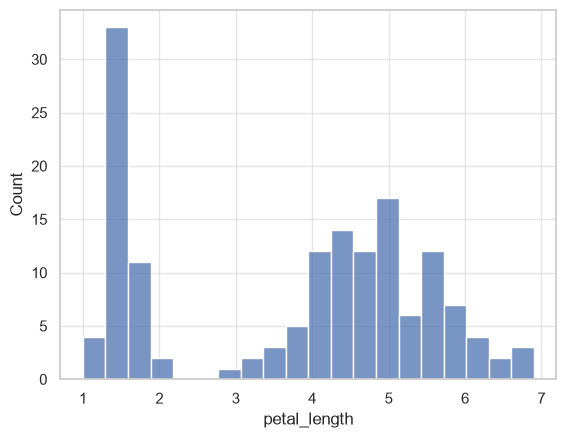

In [33]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20,
)

plt.show()

## KDE(Kernel Density Estimation)

KDE(커널 밀도 추정)는 수집한 데이터의 분포를 매끄러운 곡선 형태로 추정하여 나타내는 통계학적 방법, 히스토그램의 단점을 보완한 매끄러운 확률 밀도 그래프

히스토그램 구간의 경계 위치나 너비를 어떻게 설정하느냐에 따라서 그래프의 모양이 달라진다. 연속적인 데이터의 흐름을 반영하기가 어렵다.

### 커널(Kernel)
하나의 데이터 포인트를 대표하는 원형 형태의 작은 함수(곡선)을 의미한다.

데이터 포인트 하나가 관측되었을때, 이 값 근처에도 유사한 값이 존재할 확률이 높다 라는 것을 나타내기 위한 확률 분포 곡선













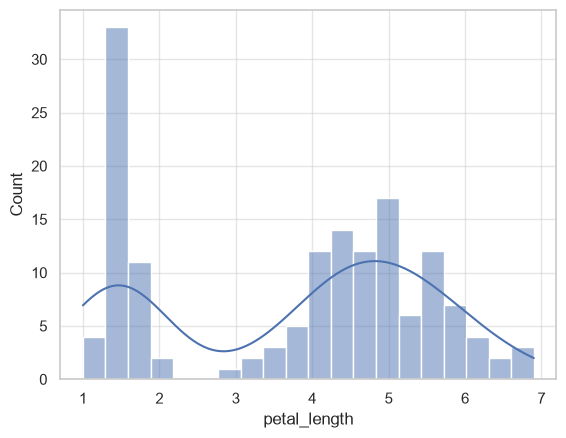

In [34]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20,
    kde=True,
)

plt.show()

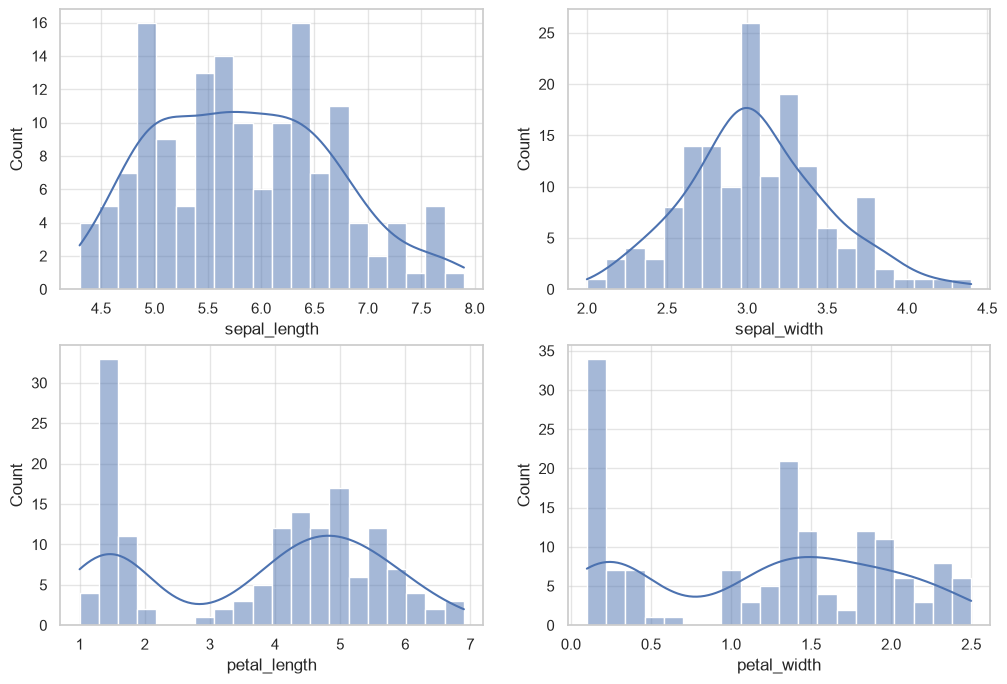

In [40]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for ax, column_name in zip(axes.flat, numeric_columns):
    sns.histplot(
        data=df,
        x=column_name,
        bins=20,
        kde=True,
        ax=ax,
    )

plt.show()

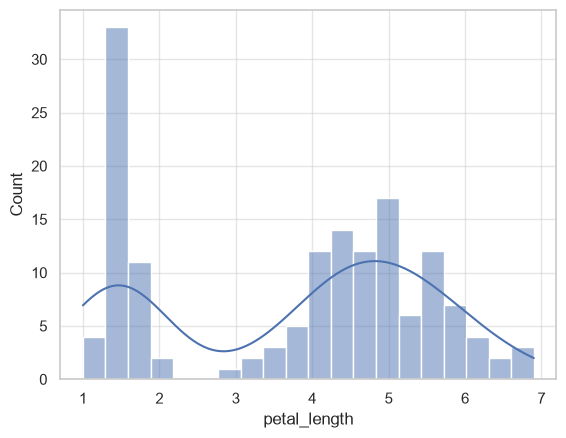

In [41]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20,
    kde=True,
)

plt.show()

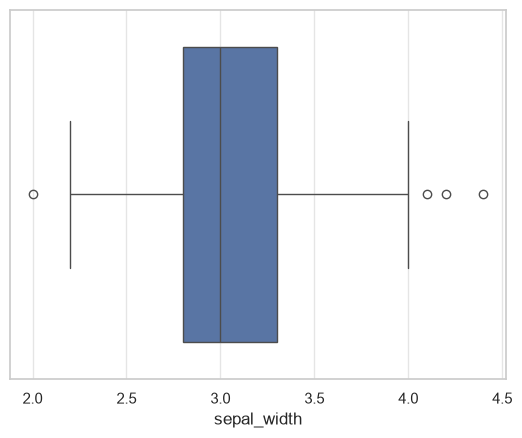

In [55]:
sns.boxplot(data=df, x='sepal_width')

plt.show()

In [50]:
q1 = df['sepal_width'].quantile(0.25)
q3 = df['sepal_width'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f'q1 = {q1}')
print(f'q3 = {q3}')
print(f'iqr = {iqr}')
print(f'lower_bound = {lower_bound}')
print(f'upper_bound = {upper_bound}')


q1 = 2.8
q3 = 3.3
iqr = 0.5
lower_bound = 2.05
upper_bound = 4.05


In [51]:
outlier = df[
    (df['sepal_width'] < lower_bound)
    |
    (df['sepal_width'] > upper_bound)
]

outlier

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


In [52]:
len(outlier)

4

In [53]:
for column_name in numeric_columns:
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # outlier = df[
    #     (df[column_name] < lower_bound)
    #     |
    #     (df[column_name] > upper_bound)
    # ]
    outlier_count = ((df[column_name] < lower_bound) | (df[column_name] > upper_bound)).sum()

    print(column_name, outlier_count)

sepal_length 0
sepal_width 4
petal_length 0
petal_width 0


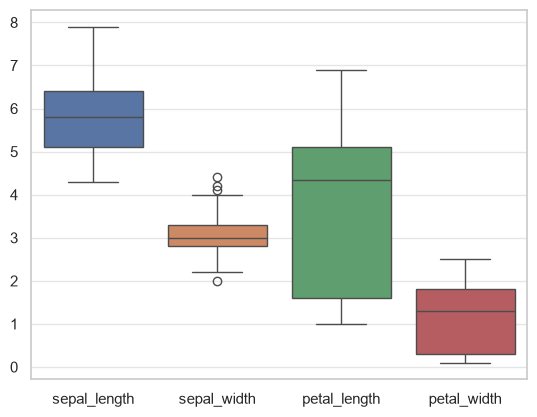

In [54]:
sns.boxplot(
    data=df[numeric_columns],
)

plt.show()

## 다변량 분석

- 수치형 + 수치형
- 범주형 + 수치형

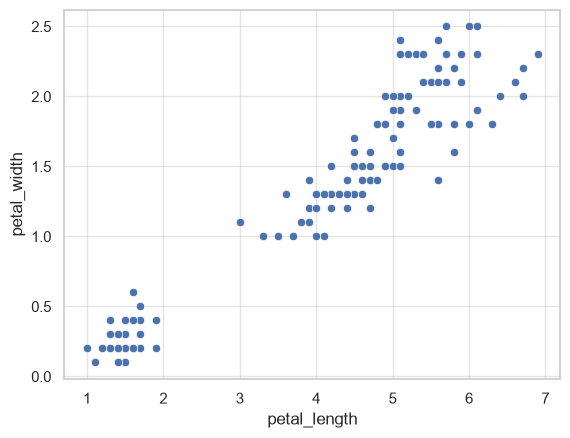

In [57]:
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
)

plt.show()